In [ ]:
from solarmach import SolarMACH,backmapping, print_body_list, get_sw_speed, get_gong_map, calculate_pfss_solution

/disk/anaconda/xw2/miniconda3/envs/sunpy_7/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


No solar wind speeds defined, trying to obtain measurements...
Using 'ACE' measurements for 'Earth'.


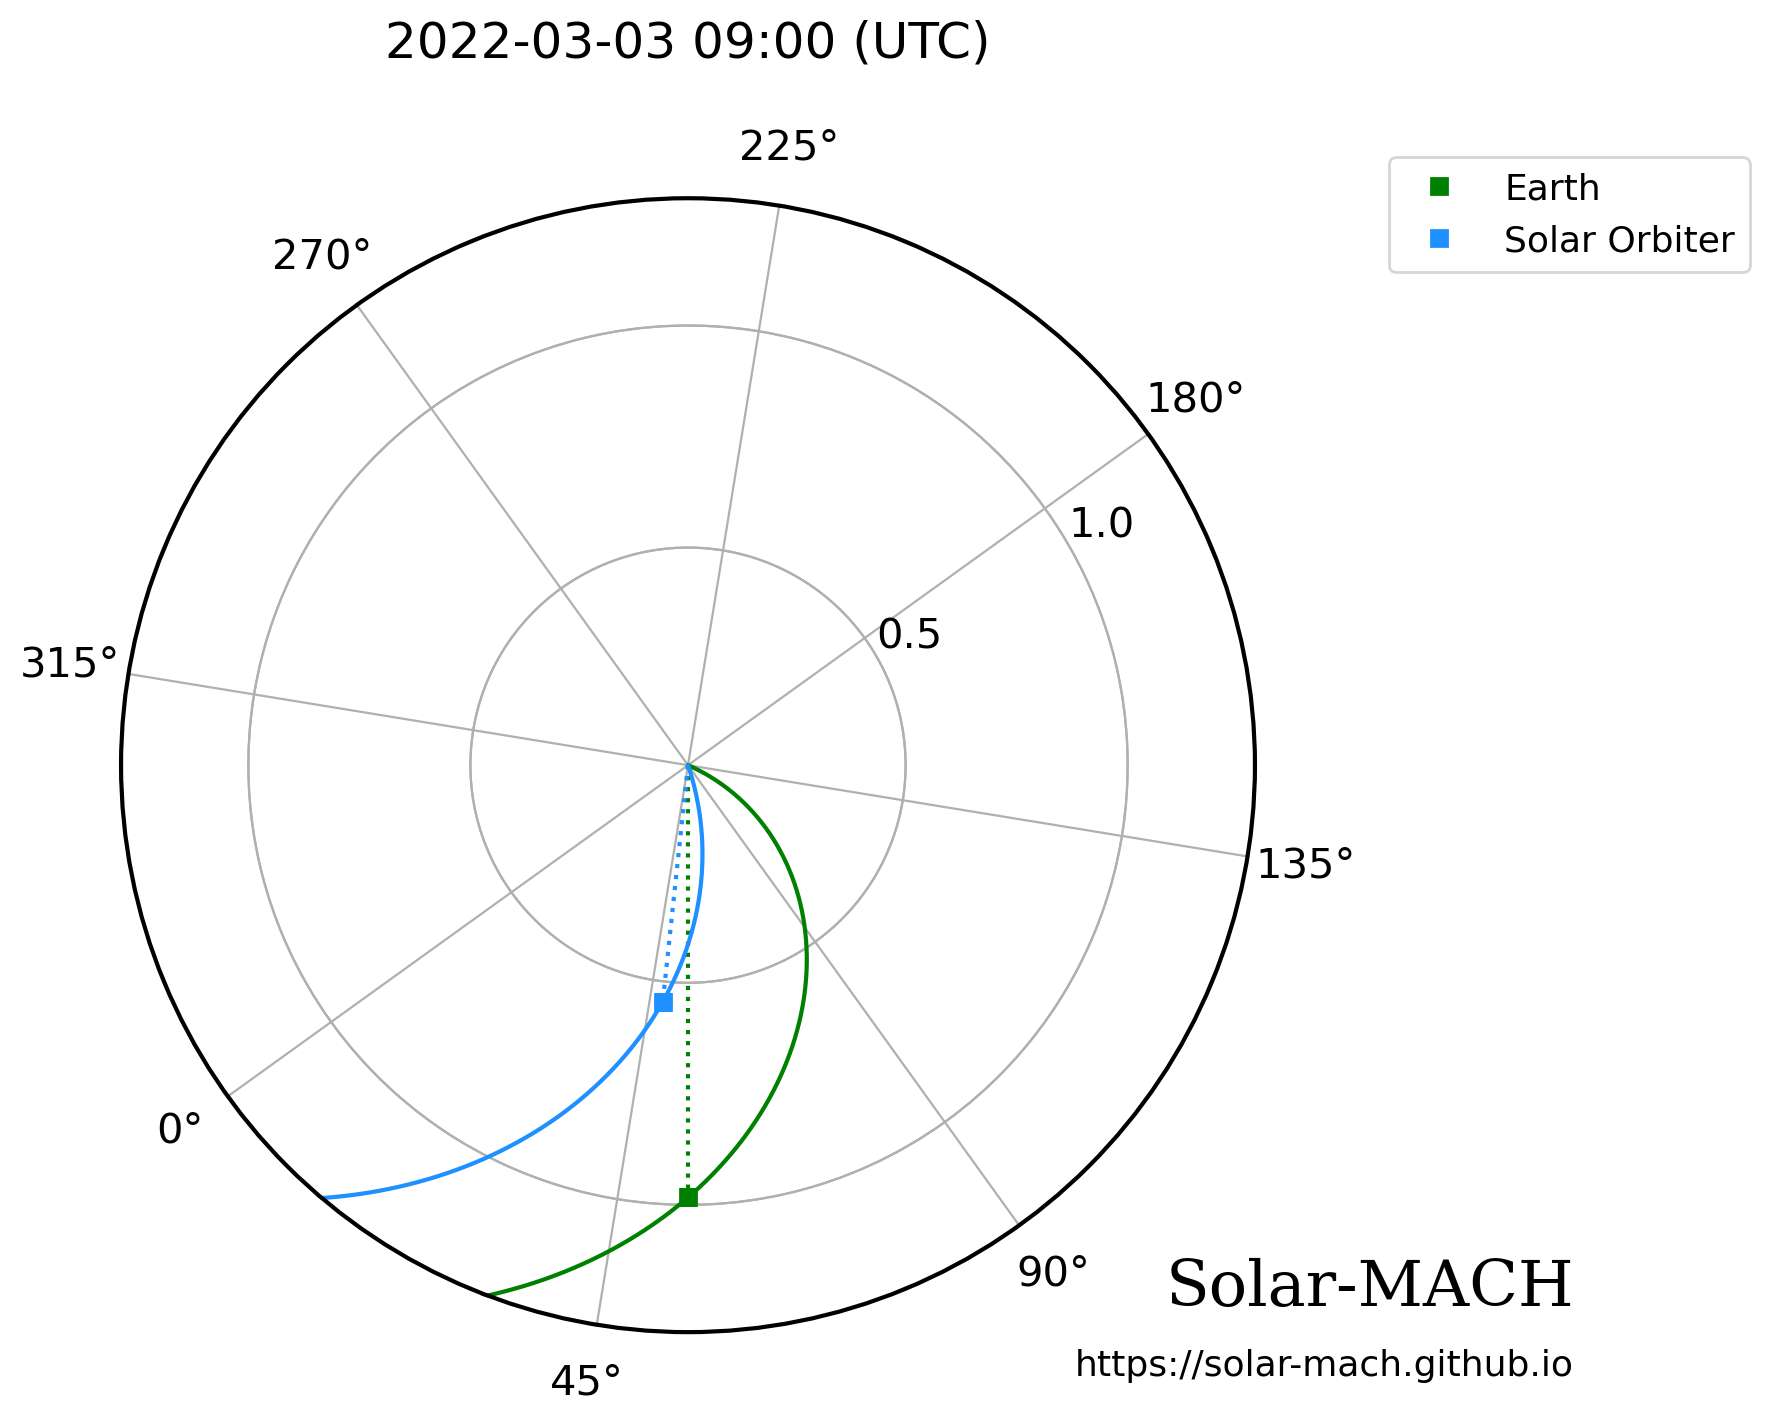

In [ ]:
body_list = ['Earth', 'Solar Orbiter']
date = '2022-3-3 09:00:00'
sm1 = SolarMACH(date=date, body_list=body_list)
# sm1.plot(plot_sun_body_line=True)

In [5]:
sm1.coord_table

,Spacecraft/Body,Carrington longitude (°),Carrington latitude (°),Heliocentric distance (AU),Longitudinal separation to Earth's longitude,Latitudinal separation to Earth's latitude,Vsw,Magnetic footpoint longitude (Carrington)
0,Earth,54.261536,-7.239979,0.99130,0.000000,0.000000,366.619995,121.077840
1,Solar Orbiter,48.171014,-4.144464,0.54715,-6.090523,3.095515,544.356201,73.100301


In [13]:
import astropy.units as u
from sunpy.time import parse_time
from sunpy.coordinates import frames, get_horizons_coord
from solarmach import backmapping

# 1) 时间
t = parse_time("2022-03-03 09:44")

# 2) 航天器位置（HORIZONS）
# 你可以用名字（如 'Solar Orbiter'）或数字 ID（如 -144）
pos = get_horizons_coord("Solar Orbiter", t, None)

# 3) 变换到 Carrington（以 Sun 为 observer）——这是 solarmach 内部的默认做法
pos_car = pos.transform_to(frames.HeliographicCarrington(observer="Sun"))

# 4) Parker spiral backmapping
sep, alpha = backmapping(
    body_pos=pos_car,
    reference_long=0.0,        # 例如：参考点经度 0°（可换成你的 flare longitude）
    target_solar_radius=2.5,   # 2.5 R☉ = source surface（文档明确说明）
    vsw=400                    # km/s
)

print(sep, alpha)


2026-01-27 17:26:41 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
81.27409776727056 33.46589012394095


In [7]:
from solarmach import SolarMACH
import astropy.units as u
from astropy.time import Time
import pandas as pd

# 1. 初始化 (假设已经做好)
body_list = ['Solar Orbiter']
date = '2022-03-03 12:00'
vsw_list = []#[400, 400, 350] * u.km / u.s

sm = SolarMACH(date=date, body_list=body_list, vsw_list=vsw_list)

# 2. 获取基础数据表
df = sm.coord_table


No solar wind speeds defined, trying to obtain measurements...


In [8]:
df

,Spacecraft/Body,Carrington longitude (°),Carrington latitude (°),Heliocentric distance (AU),Longitudinal separation to Earth's longitude,Latitudinal separation to Earth's latitude,Vsw,Magnetic footpoint longitude (Carrington)
0,Solar Orbiter,46.687432,-4.150787,0.545592,-5.927469,3.090092,511.34906,73.149353


In [11]:
# -------------------------------------------------------------------------
# 3. 手动计算离开时间 (Travel Time & Departure Time)
# -------------------------------------------------------------------------
from astropy.constants import R_sun
# 1. 定义常数
# 太阳自转角速度 (Carrington rotation rate)
# 约为 14.713 deg/day, 或者 2.865e-6 rad/s
OMEGA_SUN = 14.713 * u.deg / u.day 
# Source Surface 高度 (通常设为 2.5 个太阳半径)
R_SS = 2.5 * R_sun 

# A. 提取距离 (AU) 并转换为公里 (km)
# 注意：列名可能是 "R (AU)" 或 "Radial Distance (AU)"，视版本而定，通常是 "R (AU)"
distance_au = df['Heliocentric distance (AU)'].values * u.AU
distance_km = distance_au.to(u.km)

# B. 提取速度 (km/s)
# SolarMACH 会把速度存在 "Vsw" 列中 (如果没有该列，使用你输入的 vsw_list)
if 'Vsw' in df.columns:
    vsw_km_s = 538 * u.km / u.s #df['Vsw'].values
else:
    # 如果表格里没有，就用初始化的列表 (注意顺序要对应)
    vsw_km_s = vsw_list

# C. 计算传播时间 (秒)
travel_time = distance_km / vsw_km_s #(distance_km-R_SS)
travel_time_hours = travel_time.to(u.hour)

# D. 计算具体的离开时间 (Obs Time - Travel Time)
obs_time = Time(date)
departure_time = obs_time - travel_time

# -------------------------------------------------------------------------
# 4. 将结果添加回表格 (方便查看)
# -------------------------------------------------------------------------
df['Travel Time (hr)'] = travel_time_hours.value.round(2)
df['Departure Time'] = departure_time.iso  # 格式化为 ISO 时间字符串

print(df[['Heliocentric distance (AU)', 'Vsw', 'Travel Time (hr)', 'Departure Time']])

   Heliocentric distance (AU)        Vsw  Travel Time (hr)  \
0                    0.545592  511.34906             42.14   

            Departure Time  
0  2022-03-01 17:51:31.052  


In [ ]:
def calculate_parker_spiral_transport(r_target_km, vsw_km_s, vs_km_s=None, r_start_km=None):
    """
    计算帕克螺旋线的弧长 (Motion distance) 和粒子传输时间。
    
    参数:
    r_target_km : float -> 目标点的径向距离 (单位: km, 例如 1 AU)
    vsw_km_s    : float -> 太阳风速度 (单位: km/s, 用于定义螺旋形状 b)
    vs_km_s     : float -> 粒子沿螺旋线运动的速度 (单位: km/s, 例如电子束速度)
                           如果为 None，则只返回距离。
    r_start_km  : float -> 起始点的径向距离 (单位: km)。
                           如果不填，默认为太阳半径 (695700 km)。
                           注：通常 SEP 注入是在 Source Surface (约 2.5 Rs)。
    
    返回:
    distance_km : float -> 沿螺旋线的实际路程
    time_s      : float -> 传输时间 (秒) (如果提供了 vs_km_s)
    """
    
    # 1. 定义常量 (来自图片)
    OMEGA = 2.9e-6       # 太阳自转角速度 (rad/s)
    R_SUN = 695700.0     # 太阳半径 (km)
    
    if r_start_km is None:
        r_start_km = R_SUN

    # 2. 计算参数 b = Vsw / Omega
    # 注意：这里 Vsw 是太阳风速度，决定了磁力线的弯曲程度
    b = vsw_km_s / OMEGA

    # 3. 定义积分函数 S(r) - 对应图片中的公式 (3)
    def calculate_S_r(r, b_val):
        # 为了代码整洁，令 u = r / b
        u = r / b_val
        
        # 公式第一项: (r/2) * sqrt(1 + (r/b)^2)
        term1 = (r / 2.0) * np.sqrt(1 + u**2)
        
        # 公式第二项: (b/2) * ln( r/b + sqrt(1 + (r/b)^2) )
        # np.log 在 numpy 中即为自然对数 ln
        term2 = (b_val / 2.0) * np.log(u + np.sqrt(1 + u**2))
        
        return term1 + term2

    # 4. 计算 S(r) 和 S(r0)
    S_target = calculate_S_r(r_target_km, b)
    S_start = calculate_S_r(r_start_km, b)

    # 5. 计算沿螺旋线的实际路程 (Motion distance)
    spiral_distance_km = S_target - S_start

    # 6. 计算时间 tm (如果提供了粒子速度 vs)
    travel_time_s = None
    if vs_km_s is not None and vs_km_s > 0:
        travel_time_s = spiral_distance_km / vs_km_s

    return spiral_distance_km, travel_time_s

# ==========================================
# 示例用法
# ==========================================

# 常量转换
AU_IN_KM = 1.496e8  # 1 AU 的公里数
C_SPEED = 3e5       # 光速 km/s

# 假设条件
# 1. 观测点在地球 (1 AU)
dist_r = 0.545592 * AU_IN_KM 

# 2. 太阳风速度 (Vsw) = 400 km/s (决定螺旋线形状)
v_solar_wind = 511.349

# 3. 电子束速度 (vs) = 0.3倍光速 (粒子沿螺旋线跑的速度)
v_particle = 0.3 * C_SPEED

# 4. 起始位置: 假设从太阳表面出发 (如果不传这个参数，代码默认也是太阳表面)
dist_start = 695700.0 

# 调用函数
distance, time_sec = calculate_parker_spiral_transport(
    r_target_km=dist_r, 
    vsw_km_s=v_solar_wind, 
    vs_km_s=v_particle,
    r_start_km=dist_start
)

# 输出结果
print(f"--- 输入参数 ---")
print(f"径向距离 r: {dist_r:.2e} km (1 AU)")
print(f"太阳风速度 Vsw: {v_solar_wind} km/s")
print(f"粒子速度 vs: {v_particle:.2e} km/s")
print(f"\n--- 计算结果 ---")
print(f"螺旋线路径长度 (Arc Length): {distance:.2e} km")
print(f"相比径向直线的倍数: {distance / (dist_r - dist_start):.2f} 倍")
if time_sec:
    print(f"传输时间 (tm): {time_sec:.2f} 秒 ({time_sec/60:.2f} 分钟)")

--- 输入参数 ---
径向距离 r: 8.16e+07 km (1 AU)
太阳风速度 Vsw: 511.349 km/s
粒子速度 vs: 9.00e+04 km/s

--- 计算结果 ---
螺旋线路径长度 (Arc Length): 8.38e+07 km
相比径向直线的倍数: 1.03 倍
传输时间 (tm): 930.58 秒 (15.51 分钟)


In [29]:
import numpy as np
# 1. 正常的 SolarMACH 初始化
body_list = ['Solar Orbiter']
date = '2022-03-03 12:00'
vsw_list = [] * u.km / u.s
sm = SolarMACH(date=date, body_list=body_list, vsw_list=vsw_list)

# 获取数据表
df = sm.coord_table

# ----------------------------------------------------------------
# 2. 增加 Parker Spiral Length 计算函数
# ----------------------------------------------------------------
def calculate_spiral_length(row):
    # 获取必要的参数
    d_au = row['R (AU)'] * u.AU               # 径向距离
    v_sw = row['Vsw'] * u.km / u.s            # 太阳风速度
    
    # 太阳自转角速度 (Carrington Rotation Period ~ 25.38 days)
    # Omega = 2 * pi / T
    omega_sun = (2 * np.pi) / (25.38 * u.day)
    
    # 将单位统一为 SI (m 和 m/s) 或保持 astropy 单位运算
    D = d_au.to(u.m)
    V = v_sw.to(u.m/u.s)
    Omega = omega_sun.to(u.rad/u.s)
    
    # 计算中间变量 u = (Omega * D) / V
    # 注意：u 是无量纲的
    u_param = ((Omega * D) / V).value
    
    # 应用积分公式
    # term1 = u * sqrt(1 + u^2)
    # term2 = ln(u + sqrt(1 + u^2))
    term1 = u_param * np.sqrt(1 + u_param**2)
    term2 = np.log(u_param + np.sqrt(1 + u_param**2))
    
    length_m = (V / (2 * Omega)) * (term1 + term2)
    
    # 转换回 AU
    return length_m.to(u.AU).value

# ----------------------------------------------------------------
# 3. 应用到 DataFrame
# ----------------------------------------------------------------
# 逐行计算螺旋线长度
df['Spiral Length (AU)'] = df.apply(calculate_spiral_length, axis=1)

# 计算延迟时间 (如果是 SEP，速度接近光速 c，或者是某种粒子速度 v_particle)
# 假设是相对论性粒子，v ~ c
# df['SEP Travel Time (min)'] = (df['Spiral Length (AU)'] * u.AU / c).to(u.min)

print(df[['Heliocentric distance (AU)', 'Vsw', 'Spiral Length (AU)']])

No solar wind speeds defined, trying to obtain measurements...


AttributeError: 'Quantity' object has no 'append' member